# 01 — Data Exploration

Downloads SciFact and NFCorpus, builds qrels-only pair tables, and shows corpus statistics.

In [1]:
import sys; sys.path.insert(0, '..')
from src.utils.reproducibility import set_all_seeds
set_all_seeds(42)

## 1. Download datasets

In [2]:
from src.data.download import download_dataset

for name in ['scifact', 'nfcorpus']:
    path = download_dataset(name, out_dir='../data/raw')
    print(f'{name} -> {path}')

2026-03-28 18:19:56 | INFO     | src.data.download | Dataset 'scifact' already exists at ../data/raw/scifact — skipping.
scifact -> ../data/raw/scifact
2026-03-28 18:19:56 | INFO     | src.data.download | Dataset 'nfcorpus' already exists at ../data/raw/nfcorpus — skipping.
nfcorpus -> ../data/raw/nfcorpus


## 2. Load datasets

In [3]:
from src.data.loader import load_beir_dataset

scifact = load_beir_dataset('scifact', data_root='../data/raw')
nfcorpus = load_beir_dataset('nfcorpus', data_root='../data/raw')

2026-03-28 18:19:58 | INFO     | src.data.loader | Loading scifact from ../data/raw/scifact (split=test) ...


  0%|          | 0/5183 [00:00<?, ?it/s]

2026-03-28 18:19:58 | INFO     | src.data.loader | Loaded scifact: 5183 docs, 300 queries, 339 qrel entries
2026-03-28 18:19:58 | INFO     | src.data.loader | Loading nfcorpus from ../data/raw/nfcorpus (split=test) ...


  0%|          | 0/3633 [00:00<?, ?it/s]

2026-03-28 18:19:58 | INFO     | src.data.loader | Loaded nfcorpus: 3633 docs, 323 queries, 12334 qrel entries


## 3. Corpus statistics

In [4]:
import pandas as pd

for ds in [scifact, nfcorpus]:
    n_relevant = sum(
        1 for docs in ds.qrels.values() for label in docs.values() if label >= 1
    )
    n_qrel_pairs = sum(len(docs) for docs in ds.qrels.values())
    print(f'\n=== {ds.name} ===')
    print(f'  Corpus size:      {len(ds.corpus):>6,} docs')
    print(f'  Queries:          {len(ds.queries):>6,}')
    print(f'  Qrel pairs:       {n_qrel_pairs:>6,}')
    print(f'  Relevant pairs:   {n_relevant:>6,}')
    print(f'  Avg rel/query:    {n_relevant / len(ds.queries):.2f}')


=== scifact ===
  Corpus size:       5,183 docs
  Queries:             300
  Qrel pairs:          339
  Relevant pairs:      339
  Avg rel/query:    1.13

=== nfcorpus ===
  Corpus size:       3,633 docs
  Queries:             323
  Qrel pairs:       12,334
  Relevant pairs:   12,334
  Avg rel/query:    38.19


## 4. Relevance label distribution

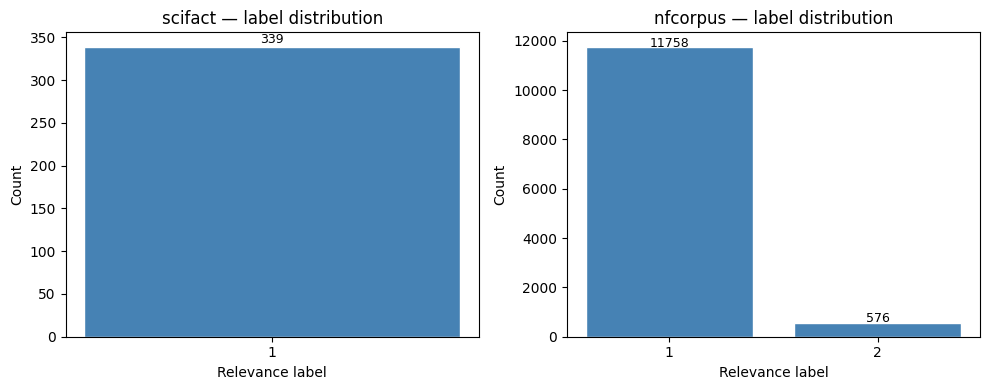

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ds in zip(axes, [scifact, nfcorpus]):
    labels = [label for docs in ds.qrels.values() for label in docs.values()]
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{ds.name} — label distribution')
    ax.set_xlabel('Relevance label')
    ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(str(i), v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/midproject/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Document length distribution

scifact: min=26, median=192, max=1524
nfcorpus: min=13, median=224, max=1460


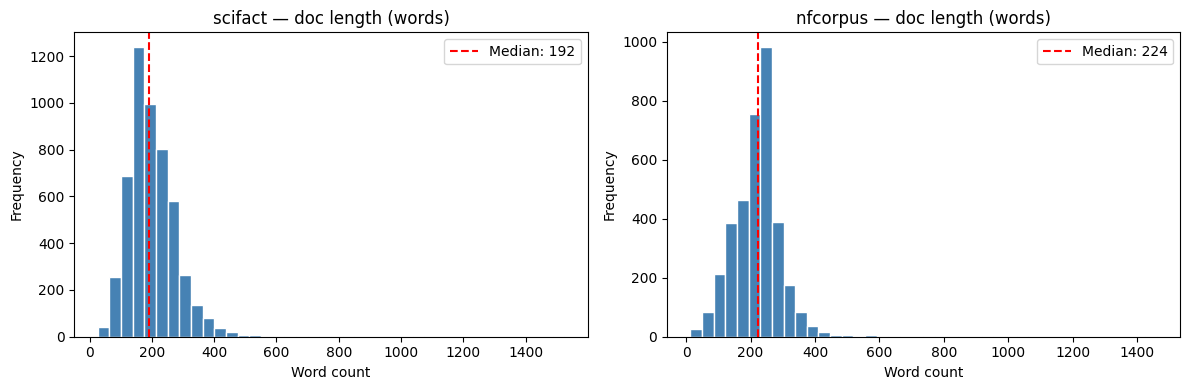

In [6]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds in zip(axes, [scifact, nfcorpus]):
    lengths = [len(doc['text'].split()) for doc in ds.corpus.values()]
    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(np.median(lengths), color='red', linestyle='--', label=f'Median: {int(np.median(lengths))}')
    ax.set_title(f'{ds.name} — doc length (words)')
    ax.set_xlabel('Word count')
    ax.set_ylabel('Frequency')
    ax.legend()
    print(f'{ds.name}: min={min(lengths)}, median={int(np.median(lengths))}, max={max(lengths)}')

plt.tight_layout()
plt.savefig('../outputs/midproject/figures/doc_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sample query-doc pairs

In [7]:
from src.data.pair_builder import build_pairs_from_qrels, save_pairs

scifact_pairs = build_pairs_from_qrels(scifact, relevance_threshold=1)
nfcorpus_pairs = build_pairs_from_qrels(nfcorpus, relevance_threshold=1)

print('SciFact sample:')
display(scifact_pairs.head(3))
print('\nNFCorpus sample:')
display(nfcorpus_pairs.head(3))

2026-03-28 18:20:17 | INFO     | src.data.pair_builder | Built qrels-only pair table: 339 pairs (339 relevant, 0 non-relevant)
2026-03-28 18:20:17 | INFO     | src.data.pair_builder | Built qrels-only pair table: 12334 pairs (12334 relevant, 0 non-relevant)
SciFact sample:


,query_id,doc_id,query_text,doc_title,doc_text,relevance_label,is_relevant,dataset
0,1,31715818,0-dimensional biomaterials show inductive prop...,New opportunities: the use of nanotechnologies...,Nanotechnologies are emerging platforms that c...,1,True,scifact
1,3,14717500,"1,000 genomes project enables mapping of genet...",Rare Variants Create Synthetic Genome-Wide Ass...,Genome-wide association studies (GWAS) have no...,1,True,scifact
2,5,13734012,1/2000 in UK have abnormal PrP positivity.,Prevalent abnormal prion protein in human appe...,OBJECTIVES To carry out a further survey of ar...,1,True,scifact



NFCorpus sample:


,query_id,doc_id,query_text,doc_title,doc_text,relevance_label,is_relevant,dataset
0,PLAIN-2,MED-2427,Do Cholesterol Statin Drugs Cause Breast Cancer?,Elevated Levels of Cholesterol-Rich Lipid Raft...,Lipid rafts/caveolae are membrane platforms fo...,2,True,nfcorpus
1,PLAIN-2,MED-10,Do Cholesterol Statin Drugs Cause Breast Cancer?,Statin Use and Breast Cancer Survival: A Natio...,"Recent studies have suggested that statins, an...",2,True,nfcorpus
2,PLAIN-2,MED-2429,Do Cholesterol Statin Drugs Cause Breast Cancer?,Statin use and risk of breast cancer: a meta-a...,Emerging evidence suggests that statins' may d...,2,True,nfcorpus


## 7. Save pair tables

In [8]:
save_pairs(scifact_pairs, 'scifact', interim_dir='../data/interim')
save_pairs(nfcorpus_pairs, 'nfcorpus', interim_dir='../data/interim')
print('Pair tables saved.')

2026-03-28 18:20:20 | INFO     | src.data.pair_builder | Saved pair table to ../data/interim/scifact/query_doc_pairs.parquet
2026-03-28 18:20:20 | INFO     | src.data.pair_builder | Saved pair table to ../data/interim/nfcorpus/query_doc_pairs.parquet
Pair tables saved.


## 8. Verify saved parquet

In [9]:
from src.utils.io import load_parquet

for name in ['scifact', 'nfcorpus']:
    df = load_parquet(f'../data/interim/{name}/query_doc_pairs.parquet')
    print(f'{name}: {len(df)} rows, {df["is_relevant"].sum()} relevant, columns={list(df.columns)}')

scifact: 339 rows, 339 relevant, columns=['query_id', 'doc_id', 'query_text', 'doc_title', 'doc_text', 'relevance_label', 'is_relevant', 'dataset']
nfcorpus: 12334 rows, 12334 relevant, columns=['query_id', 'doc_id', 'query_text', 'doc_title', 'doc_text', 'relevance_label', 'is_relevant', 'dataset']


# Plan: LLM Reranker Mechanistic Interpretability Project

## Context
This is a research project studying *what internal features an LLM uses to judge relevance* when deployed as a pointwise reranker, and whether those features are causally active in ranking decisions. The approach combines layer-wise linear probing with compulsory Sparse Autoencoder (SAE) analysis at three depth levels, followed by causal interventions via probe-direction steering and SAE feature manipulation.

The project is a fresh, empty git repo at `/Users/vraj21/Desktop/Projects/LLM Reranker/`.

---

## Model and Datasets

**Model:** `Qwen/Qwen2.5-1.5B-Instruct` (Apache-2.0, free)
- 28 transformer decoder layers, hidden dim 1536
- HuggingFace: https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct
- Run single-model first; add Mistral-7B-Instruct-v0.3 only after full pipeline works

**Primary dataset:** BEIR SciFact — 1,109 docs, 300 queries, binary labels
- https://huggingface.co/datasets/BeIR/scifact
- Load via `beir` package: `GenericDataLoader(data_path).load(split="test")`

**OOD dataset:** BEIR NFCorpus — 3,633 docs, 323 queries, graded labels 0/1/2
- https://huggingface.co/datasets/BeIR/nfcorpus

---

## Directory Structure

```
LLM Reranker/
├── README.md
├── requirements.txt
├── requirements-dev.txt
├── setup.py
├── .gitignore
├── .env.example
│
├── configs/
│   ├── base.yaml              # seed, device, root paths
│   ├── data.yaml              # dataset names, splits, max_length
│   ├── retrieval.yaml         # BM25 k1=1.5, b=0.75, top_k=20
│   ├── reranker.yaml          # prompt template, score range 0-3, batch_size
│   ├── activations.yaml       # hook layers, token position strategy
│   ├── features.yaml          # feature definitions, doc_length bins
│   ├── probing.yaml           # probe types, alpha grid, cv_folds=5
│   ├── sae.yaml               # k=32, expansion_factor=8, lr=1e-4, target_layers=[7,14,21]
│   ├── interventions.yaml     # alpha magnitudes, target layers, directions
│   └── evaluation.yaml        # metric cutoffs (nDCG@10, MRR@10, Recall@20)
│
├── data/
│   ├── raw/
│   │   ├── scifact/           # corpus.jsonl, queries.jsonl, qrels/test.tsv
│   │   └── nfcorpus/
│   ├── interim/
│   │   ├── scifact/           # query_doc_pairs.parquet, bm25_top20.parquet
│   │   └── nfcorpus/
│   ├── processed/
│   │   ├── scifact/           # reranker_scores.parquet, features.parquet, activations_meta.parquet
│   │   └── nfcorpus/
│   └── caches/
│       ├── activations/
│       │   ├── scifact/       # layer_{i}.npy (shape: n_pairs × 1536, float16)
│       │   └── nfcorpus/
│       └── bm25_indexes/
│           ├── scifact/       # bm25_index.pkl, corpus_ids.json
│           └── nfcorpus/
│
├── src/
│   ├── data/
│   │   ├── download.py        # BEIR downloader
│   │   ├── loader.py          # GenericDataLoader wrapper
│   │   ├── pair_builder.py    # construct query-doc pair tables
│   │   └── schema.py          # dataclass definitions
│   ├── retrieval/
│   │   ├── bm25_index.py      # build + serialize BM25 index
│   │   ├── bm25_retriever.py  # query top-k with scores
│   │   └── evaluate_retrieval.py
│   ├── reranking/
│   │   ├── prompt_builder.py  # pointwise prompt (0-3 scale)
│   │   ├── qwen_inference.py  # batched Qwen forward pass
│   │   ├── score_parser.py    # regex extract int from output
│   │   └── evaluate_reranker.py
│   ├── activations/
│   │   ├── hooks.py           # register/remove PyTorch forward hooks on model.model.layers[i]
│   │   ├── extractor.py       # drive extraction loop, write .npy caches
│   │   ├── token_position.py  # centralized decision token position logic (input_ids.shape[1]-1)
│   │   └── cache_manager.py   # load + validate activation caches
│   ├── features/
│   │   ├── lexical_overlap.py # |Q∩D|/|Q| using whitespace tokenization
│   │   ├── query_term_freq.py # mean tf of query terms in doc
│   │   ├── doc_length.py      # word count + quartile bucket
│   │   ├── bm25_features.py   # expose BM25 score/rank as feature
│   │   └── feature_table.py   # join all features → features.parquet
│   ├── probing/
│   │   ├── probe_trainer.py   # Ridge/Logistic per (layer, target)
│   │   ├── probe_evaluator.py # R², AUROC per layer
│   │   ├── layerwise_results.py
│   │   └── probe_store.py     # persist probe weights (used as steering directions)
│   ├── sae/
│   │   ├── model.py           # TopK SAE: encoder Linear→TopK→ReLU, decoder Linear (cols unit-normed)
│   │   ├── trainer.py         # MSE loss only, Adam, normalize decoder columns each step
│   │   ├── evaluator.py       # reconstruction MSE, L0, dead feature %
│   │   ├── feature_analyzer.py # top-activating examples, Pearson corr with IR features
│   │   └── sae_store.py       # checkpoint save/load
│   ├── interventions/
│   │   ├── probe_steering.py  # inject ±αw into residual stream at decision token via hook
│   │   ├── sae_feature_steering.py  # amplify SAE decoder column direction
│   │   ├── sae_ablation.py    # zero out SAE feature activations inline
│   │   └── intervention_eval.py    # measure nDCG/MRR delta, paired t-test
│   ├── evaluation/
│   │   ├── metrics.py         # nDCG@10, MRR@10, Recall@20
│   │   └── results_table.py
│   ├── visualization/
│   │   ├── probe_heatmap.py   # layers × targets heatmap (R²/AUROC)
│   │   ├── probe_lineplot.py  # per-target line plot with CI bands
│   │   ├── sae_feature_viz.py # activation histograms, top example grids
│   │   ├── intervention_plot.py # delta bar charts per intervention
│   │   └── style.py           # matplotlib rcParams
│   ├── analysis/
│   │   ├── phase6_summary.py  # mid-project checkpoint report
│   │   └── final_summary.py
│   └── utils/
│       ├── config.py          # OmegaConf yaml loader
│       ├── logging.py
│       ├── reproducibility.py # set all seeds (torch, numpy, random, transformers)
│       └── io.py              # parquet/npy helpers
│
├── notebooks/
│   ├── 00_environment_check.ipynb
│   ├── 01_data_exploration.ipynb
│   ├── 02_bm25_baseline.ipynb
│   ├── 03_reranker_evaluation.ipynb
│   ├── 04_activation_inspection.ipynb
│   ├── 05_feature_engineering.ipynb
│   ├── 06_probing_results.ipynb
│   ├── 06b_midproject_checkpoint.ipynb   ← MID-PROJECT UPDATE
│   ├── 07_sae_analysis.ipynb
│   ├── 08_interventions.ipynb
│   ├── 09_ood_robustness.ipynb
│   └── 10_final_figures.ipynb
│
├── scripts/
│   ├── phase0_setup.sh
│   ├── phase1_data.sh
│   ├── phase2_retrieval.sh
│   ├── phase3_reranking.sh
│   ├── phase4_activations.sh
│   ├── phase5_features.sh
│   ├── phase6_probing.sh
│   ├── phase7_sae.sh
│   ├── phase8_interventions.sh
│   ├── phase9_ood.sh
│   └── run_all.sh
│
├── tests/
│   ├── test_data/mini_corpus.jsonl
│   ├── test_pair_builder.py
│   ├── test_bm25.py
│   ├── test_prompt_builder.py
│   ├── test_score_parser.py
│   ├── test_hooks.py
│   ├── test_features.py
│   ├── test_probe_trainer.py
│   ├── test_sae_model.py
│   └── test_metrics.py
│
├── outputs/
│   ├── midproject/
│   │   ├── figures/
│   │   ├── tables/
│   │   └── report.md
│   └── final/
│       ├── figures/
│       ├── tables/
│       ├── probe_weights/     # layer{i}_{target}.pkl files used as steering directions
│       ├── sae_checkpoints/   # layer7/, layer14/, layer21/
│       └── report.md
│
├── docs/
│   ├── research_protocol.md
│   ├── data_schema.md
│   ├── sae_design.md
│   └── intervention_protocol.md
│
└── slides/
    ├── proposal/
    ├── midproject/
    └── final/
```

---

## Phase Plan

### Phase 0 — Repository Setup
**Goal:** Reproducible environment before any code runs.

**Deliverables:**
- `requirements.txt` pinned: `torch>=2.1`, `transformers>=4.40`, `datasets`, `beir`, `rank_bm25`, `scikit-learn`, `numpy`, `pandas`, `pyarrow`, `omegaconf`, `matplotlib`, `seaborn`, `tqdm`, `pytest`
- All `configs/*.yaml` files authored with defaults
- `src/utils/reproducibility.py` (seed = 42 everywhere)
- `.gitignore` excluding `data/raw/`, `data/caches/`, `*.npy`, `sae_checkpoints/`, HF cache, `.env`
- `notebooks/00_environment_check.ipynb` verifying GPU, HF model load, package versions

---

### Phase 1 — Data Preparation
**Goal:** Download BEIR SciFact + NFCorpus, validate schema, build query-doc pair tables.

**Key files:** `src/data/download.py`, `src/data/pair_builder.py`

**Deliverables:**
- `data/raw/scifact/` and `data/raw/nfcorpus/`
- `data/interim/{dataset}/query_doc_pairs.parquet` — columns: `query_id, doc_id, query_text, doc_title, doc_text, relevance_label, is_relevant, dataset`
- `notebooks/01_data_exploration.ipynb` with corpus statistics

**Key notes:**
- Use `beir` package `GenericDataLoader`; SciFact labels are binary (0/1), NFCorpus graded (0/1/2)
- `is_relevant = label >= 1` for both datasets (consistent probe target)
- Pair builder supports `mode=qrels_only` (Phase 1) and `mode=top_k_from_run` (Phase 2+)

---

### Phase 2 — BM25 Retrieval Baseline
**Goal:** Build BM25 index, retrieve top-20 candidates, establish retrieval metrics.

**Key files:** `src/retrieval/bm25_index.py`, `src/retrieval/bm25_retriever.py`

**Deliverables:**
- `data/caches/bm25_indexes/scifact/bm25_index.pkl` + `corpus_ids.json`
- `data/interim/scifact/bm25_top20.parquet` — columns: `query_id, doc_id, bm25_rank, bm25_score`
- Baseline nDCG@10, MRR@10, Recall@20 for both datasets
- `notebooks/02_bm25_baseline.ipynb`

**Key notes:**
- `rank_bm25.BM25Okapi` with whitespace tokenization; `k1=1.5, b=0.75` from config
- After retrieval, rebuild `query_doc_pairs.parquet` as union of top-20 candidates (includes non-relevant) with `bm25_score` and `bm25_rank` added — this is the working pair table henceforth
- Retrieve top-20 first; top-50 tested later in Phase 9

---

### Phase 3 — Pointwise LLM Reranker
**Goal:** Score each (query, doc) pair with Qwen2.5-1.5B-Instruct, measure reranking improvement.

**Key files:** `src/reranking/prompt_builder.py`, `src/reranking/qwen_inference.py`, `src/reranking/score_parser.py`

**Deliverables:**
- `data/processed/scifact/reranker_scores.parquet` — columns: `query_id, doc_id, reranker_score, reranker_rank`
- nDCG@10, MRR@10, Recall@20 for LLM reranker vs BM25
- Score distribution by relevance label (sanity check)
- `notebooks/03_reranker_evaluation.ipynb`

**Prompt template (stored in `configs/reranker.yaml`):**
```
System: You are an expert relevance assessor.
User: Rate how relevant the document is to the query on a scale of 0 to 3:
  0: Not relevant | 1: Marginally relevant | 2: Relevant | 3: Highly relevant
Query: {query}
Document: {doc_text[:512]}
Respond with a single integer (0, 1, 2, or 3).
```

**Key notes:**
- **Decision token position** = `input_ids.shape[1] - 1` (last input token before generation) — this position is used in Phase 4 for activation extraction; centralize in `src/activations/token_position.py`
- Score parser: regex `r'\b([0-3])\b'` on first 20 chars of decoded output; fallback to 0; log fallback rate (must be < 5%)
- Batched inference: batch_size=8-16, `torch.no_grad()`, `model.half()` (float16)

---

### Phase 4 — Activation Extraction
**Goal:** Extract residual stream hidden states at the decision token position from all 28 layers.

**Key files:** `src/activations/hooks.py`, `src/activations/extractor.py`, `src/activations/cache_manager.py`

**Deliverables:**
- 28 `.npy` files per dataset under `data/caches/activations/{dataset}/layer_{i}.npy`, shape `(n_pairs, 1536)`, dtype `float16`
- `manifest.json` — maps layer indices → filenames, stores ordered `(query_id, doc_id)` list, records `decision_token_strategy`, `model_id`, `n_pairs`, `hidden_dim`
- `notebooks/04_activation_inspection.ipynb` with PCA/UMAP sanity checks

**Key notes:**
- Hook on `model.model.layers[i]` output tuple element 0 (residual stream); verify Qwen's layer output structure first with a test hook
- Extract all 28 layers in one forward pass (not 28 separate passes): register all hooks, run forward, demux to per-layer arrays
- Memory: 6,000 pairs × 28 layers × 1536 × 2 bytes (float16) ≈ 490MB total — manageable
- Remove all hooks after extraction: `for h in handles: h.remove()`
- `cache_manager.py` validates shape, no NaN/Inf, row ordering matches manifest — call this at start of Phases 6 and 7

---

### Phase 5 — Feature Engineering
**Goal:** Compute all IR probe targets for every (query, doc) pair.

**Key files:** `src/features/feature_table.py` and feature modules

**Probe target table (features.parquet):**

| Feature | Type | Implementation | Probe |
|---|---|---|---|
| `lexical_overlap` | float [0,1] | \|Q∩D tokens\| / \|Q tokens\| | Ridge |
| `qtf` | float | mean tf of query terms in doc | Ridge |
| `doc_length_bucket` | int {0,1,2,3} | quartile bucket of word count | Logistic |
| `bm25_score` | float | from Phase 2 | Ridge |
| `bm25_rank` | int [1,20] | from Phase 2 | Ridge |
| `is_relevant` | bool | label >= 1 | Logistic |
| `relevance_label` | int | raw BEIR label | Ridge |

**Key notes:**
- Use whitespace `.lower().split()` tokenization for all lexical features (not Qwen subword tokenizer)
- `doc_length_bucket` quartile boundaries computed on full corpus, not just top-20 candidates
- `features.parquet` must be joinable to activation cache rows via same `(query_id, doc_id)` ordering in manifest — assert row count equality before probing
- `notebooks/05_feature_engineering.ipynb` shows feature distributions and correlation matrix

---

### Phase 6 — Linear Probing
**Goal:** Train one probe per (layer, target) pair; visualize IR signal emergence across depth.

**Key files:** `src/probing/probe_trainer.py`, `src/probing/probe_evaluator.py`, `src/probing/probe_store.py`

**Deliverables:**
- Probe metrics matrix: shape `(28 layers, 7 targets)` — R² for regression, AUROC for classification
- Layer-wise heatmap figure (rows=layers, cols=targets, color=metric)
- Per-target line plots across layers with 95% CI bands (bootstrap n=1000)
- `outputs/midproject/tables/probe_results.csv`
- Saved probe weights at `outputs/final/probe_weights/layer{i}_{target}.pkl` (used as steering directions in Phase 8)
- `notebooks/06_probing_results.ipynb`

**Key notes:**
- 80/20 train/test split stratified by `is_relevant`; 5-fold CV for hyperparameter selection
- Ridge: `sklearn Ridge(alpha=1.0)`, StandardScaler fit on train only; alpha grid `[0.01, 0.1, 1.0, 10.0, 100.0]`
- Logistic: `LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')`; C grid same values
- Report bootstrap 95% CI on test-set metrics (n_pairs ~6,000 is small, CIs matter)
- Hypotheses to state *before* running (in `docs/research_protocol.md`): lexical overlap peaks early-mid; relevance label peaks late; BM25 score strongest in mid-late

---

## ★ MID-PROJECT UPDATE CHECKPOINT (after Phase 6) ★

**Notebook:** `notebooks/06b_midproject_checkpoint.ipynb`
**Slides:** `slides/midproject/`

**Required content:**
1. BM25 baseline metrics (nDCG@10, MRR@10, Recall@20) on SciFact
2. LLM reranker metrics vs BM25 — does Qwen2.5-1.5B improve ranking?
3. Score parser fallback rate (must be < 5%)
4. Probe heatmap — first mechanistic result
5. Which layers show strongest signal per target
6. Identified SAE target layers (confirm or update from 7/14/21 defaults)
7. Open questions, blockers, next steps

**Go/No-Go criteria:**
- Reranker shows non-trivial nDCG@10
- At least 3/7 probe targets show R² > 0.1 or AUROC > 0.6 in at least one layer
- Activation cache fully validated

---

### Phase 7 — Sparse Autoencoder Training (COMPULSORY)
**Goal:** Train TopK SAEs at layers 7, 14, 21 to decompose representations into sparse interpretable features.

**Key files:** `src/sae/model.py`, `src/sae/trainer.py`, `src/sae/feature_analyzer.py`

**Deliverables:**
- SAE checkpoints at `outputs/final/sae_checkpoints/layer{7,14,21}/`
- Reconstruction MSE, L0 sparsity, dead feature % per SAE (dead features target < 5%)
- Top-20 activating examples per feature at each layer
- Pearson correlation of SAE feature activations with IR features (probe targets)
- `notebooks/07_sae_analysis.ipynb`

**TopK SAE architecture (`src/sae/model.py`):**
```python
class TopKSAE(nn.Module):
    def __init__(self, input_dim=1536, expansion_factor=8, k=32):
        # hidden_dim = 1536 * 8 = 12288
        # encoder: Linear(1536 → 12288) → TopK(k=32) → ReLU
        # decoder: Linear(12288 → 1536) with columns normalized to unit norm

    def forward(self, x):
        x_centered = x - self.decoder.bias  # center before encoding
        sparse = self.encode(x_centered)     # TopK sparse codes
        x_hat = self.decoder(sparse)         # reconstruct
        return x_hat, sparse
```

**Training notes:**
- Loss = MSE(x, x_hat) only — TopK enforces sparsity structurally, no L1 penalty
- Normalize decoder columns to unit norm after each gradient step (prevent trivial solution)
- Adam lr=1e-4, batch_size=2048, 50 epochs, 10% validation split
- **Training data:** extract activations at ALL sequence positions (not just decision token) across all prompts — yields ~60-120K vectors per layer (standard SAE training approach); `configs/sae.yaml: activation_source: all_positions`
- Three SAEs cover: early (layer 7) ≈ surface/lexical signals, middle (layer 14) ≈ matching/interaction, late (layer 21) ≈ decision/formatting signals
- Feature interpretation: for each feature, find top-20 (query,doc) pairs by activation strength; compute Pearson r with all IR features; high-correlation features are prime intervention targets

---

### Phase 8 — Causal Interventions
**Goal:** Test whether representations are *causally* active in ranking via probe-direction steering and SAE feature manipulation.

**Key files:** `src/interventions/probe_steering.py`, `src/interventions/sae_feature_steering.py`, `src/interventions/sae_ablation.py`, `src/interventions/intervention_eval.py`

**Deliverables:**
- nDCG@10, MRR@10 delta tables for: baseline, ±α probe steering (per target, per layer), SAE feature steering, SAE feature ablation
- Dose-response curve: alpha magnitude vs ΔnDCG (alpha values: ±1, ±3, ±5 × ‖w‖)
- Score shift histograms before/after intervention
- Paired t-test significance for each intervention
- `notebooks/08_interventions.ipynb`

**Probe-direction steering (PyTorch hook pattern):**
```python
def make_steering_hook(direction, alpha, token_pos):
    # direction: (1536,) unit-normalized probe weight vector
    def hook(module, input, output):
        hidden = output[0]  # (batch, seq_len, hidden_dim)
        hidden[:, token_pos, :] += alpha * direction
        return (hidden,) + output[1:]
    return hook
# Register on model.model.layers[l], run inference, remove hook
```

**SAE feature ablation hook:**
```python
def make_sae_ablation_hook(sae, feature_indices, token_pos):
    def hook(module, input, output):
        hidden = output[0]
        h = hidden[:, token_pos, :]
        sparse = sae.encode(h - sae.decoder.bias)
        sparse[:, feature_indices] = 0.0  # ablate
        hidden[:, token_pos, :] = sae.decoder(sparse)
        return (hidden,) + output[1:]
    return hook
```

**Evaluation:** For each intervention, rerun full reranking on all 300 SciFact queries. Compute ΔnDCG@10 and ΔMRR@10 vs baseline. Monitor output collapse (all scores → same value). Report paired t-test across queries.

---

### Phase 9 — Robustness and OOD Analysis
**Goal:** Test generalization to NFCorpus; test sensitivity to prompt variants and retrieval depth.

**Deliverables:**
- Full pipeline results for NFCorpus (BM25, reranker, probing, key interventions)
- Cross-dataset probe transfer: train probe on SciFact activations, evaluate on NFCorpus activations
- Prompt variant experiment: 3 alternative prompts, measure reranker metric variance
- Top-50 candidate experiment: extend retrieval depth, re-evaluate reranker
- `notebooks/09_ood_robustness.ipynb`

**Key notes:**
- Cross-dataset probe transfer is the strongest generalization claim: if SciFact probe generalizes to NFCorpus, the representation is domain-general
- NFCorpus graded labels (0/1/2) give richer `relevance_label` regression target
- Prompt variants: (1) remove rubric text, (2) use 0-10 scale, (3) flip query/doc order

---

### Phase 10 — Final Analysis and Visualization
**Goal:** Publication-quality figures, final tables, and written report.

**Required figures:**
- Figure 1: Layerwise probe heatmap (28 rows × 7 cols, color = R²/AUROC) — primary MI result
- Figure 2: Per-target line plots across depth with 95% CI bands
- Figure 3: SAE feature activation examples grid (early vs middle vs late layer comparison)
- Figure 4: Intervention delta bar charts (ΔnDCG per intervention × layer)
- Figure 5: Cross-dataset probe transfer heatmap
- Figure 6: Score distribution by relevance label (sanity/baseline)

**Required tables:**
- Table 1: BM25 vs LLM reranker metrics (both datasets, all cutoffs)
- Table 2: Best probe R²/AUROC per target + layer of peak performance
- Table 3: SAE reconstruction MSE, L0, dead feature % per layer
- Table 4: Intervention effect sizes with significance (p-values from paired t-test)

---

## Cross-Cutting Implementation Rules

1. **Decision token consistency:** Every module that references the decision token position imports from `src/activations/token_position.py` — never hardcode `input_ids.shape[1]-1` inline
2. **Config-driven:** Every hardcoded number (layer count, K, top_k, hidden_dim) lives in a YAML config — never hardcode in source
3. **Reproducibility:** `src/utils/reproducibility.py` sets `torch.manual_seed(42)`, `numpy.random.seed(42)`, `random.seed(42)`, `transformers.set_seed(42)` — called at top of every script and notebook
4. **Cache validation:** `cache_manager.py` asserts shape, no NaN/Inf, row ordering vs manifest — called at start of Phases 6 and 7
5. **Qwen architecture:** Verify `model.model.layers` is the correct hook target by printing layer names before Phase 4; layer output tuple structure may differ from LLaMA

## Verification

- Phase 2: BM25 nDCG@10 on SciFact should be ~0.65-0.70 (known baseline)
- Phase 3: Score parser fallback rate < 5%; score distribution should correlate with relevance labels
- Phase 4: Activation shapes must be exactly `(n_pairs, 1536)` per layer; PCA of layer 0 vs layer 27 should differ visually
- Phase 6: At least 3 probe targets show R² > 0.1 or AUROC > 0.6 somewhere; heatmap should show clear layerwise structure
- Phase 7: SAE reconstruction MSE should decrease monotonically during training; dead features < 5%
- Phase 8: At least one intervention should show ΔnDCG ≠ 0 with p < 0.05
- Phase 9: Cross-dataset probe transfer R² should be positive (generalization check)
